In [2]:
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()
#Define figure sizes
plt.rcParams.update({'figure.figsize': (8, 5), 'figure.dpi': 120})

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine Learning libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import scipy as sp

# Others
from utils import ts_display, check_residuals, boxcox_lambda_plot
import scipy.stats as st

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
sns.set()

#Define figure sizes
#plt.rcParams.update({'figure.figsize': (8, 5), 'figure.dpi': 120})

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from dateutil.parser import parse 

# Machine Learning libraries
from statsmodels.tsa.seasonal import seasonal_decompose, STL
# Others
import math



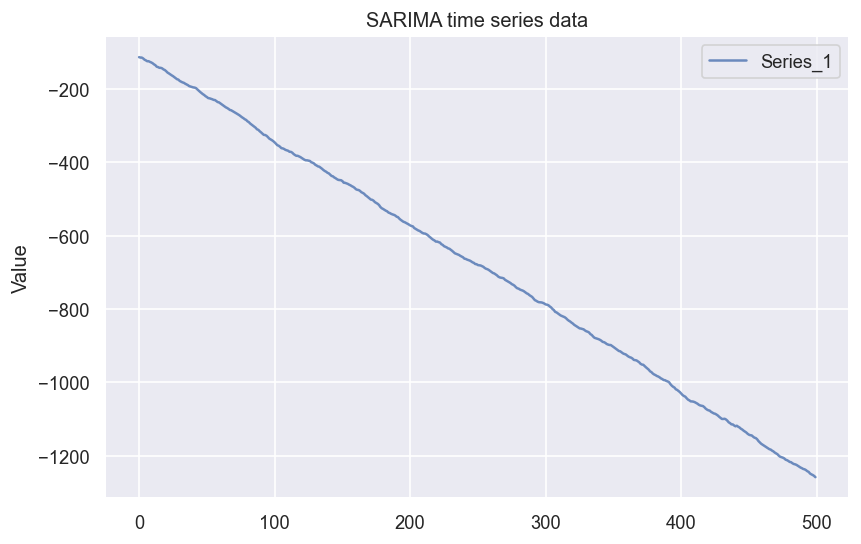

In [6]:
# Plotting a time series
fig, ax = plt.subplots()
for col in df_1.columns.values.tolist():
    ax.plot(col, data=df_1, label=col, alpha=0.8)
ax.set(title='SARIMA time series data', ylabel='Value')
plt.legend()
plt.show()

In [152]:
# Import data
#df = pd.read_csv('SARIMA.csv',sep=';')
df = pd.read_csv('SARIMA_Hackathon_data.csv',sep=',')
df.head()

# Crear DataFrames separados para cada serie temporal
df_1 = df[['Series_1']]  # DataFrame con la columna 'Series_1'
df_2 = df[['Series_2']]  # DataFrame con la columna 'Series_2'
df_3 = df[['Series_3']]  # DataFrame con la columna 'Series_3'
df_4 = df[['Series_4']]  # DataFrame con la columna 'Series_4'
df_5 = df[['Series_5']]  # DataFrame con la columna 'Series_5'
df_6 = df[['Series_6']]  # DataFrame con la columna 'Series_6'
df_7 = df[['Series_7']]  # DataFrame con la columna 'Series_7'
df_8 = df[['Series_8']]  # DataFrame con la columna 'Series_8'

# Mostrar uno de los DataFrames como ejemplo
df_7


,Series_7
0,4.029355
1,4.409704
2,5.313123
3,8.803809
4,7.073443
...,...
495,-907.863131
496,-917.631953
497,-939.821125
498,-943.621629


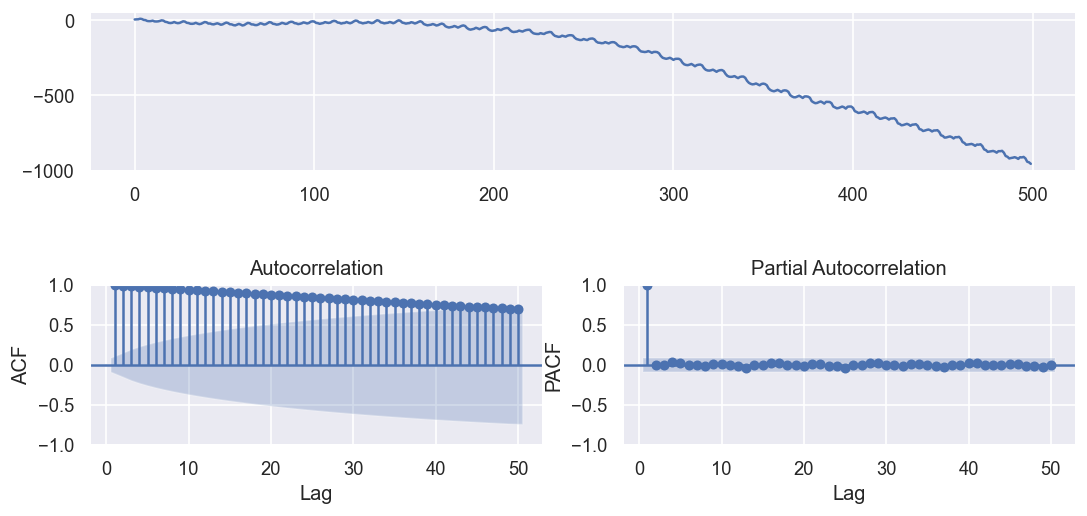

In [154]:

ts_display(df_7,lags=50)

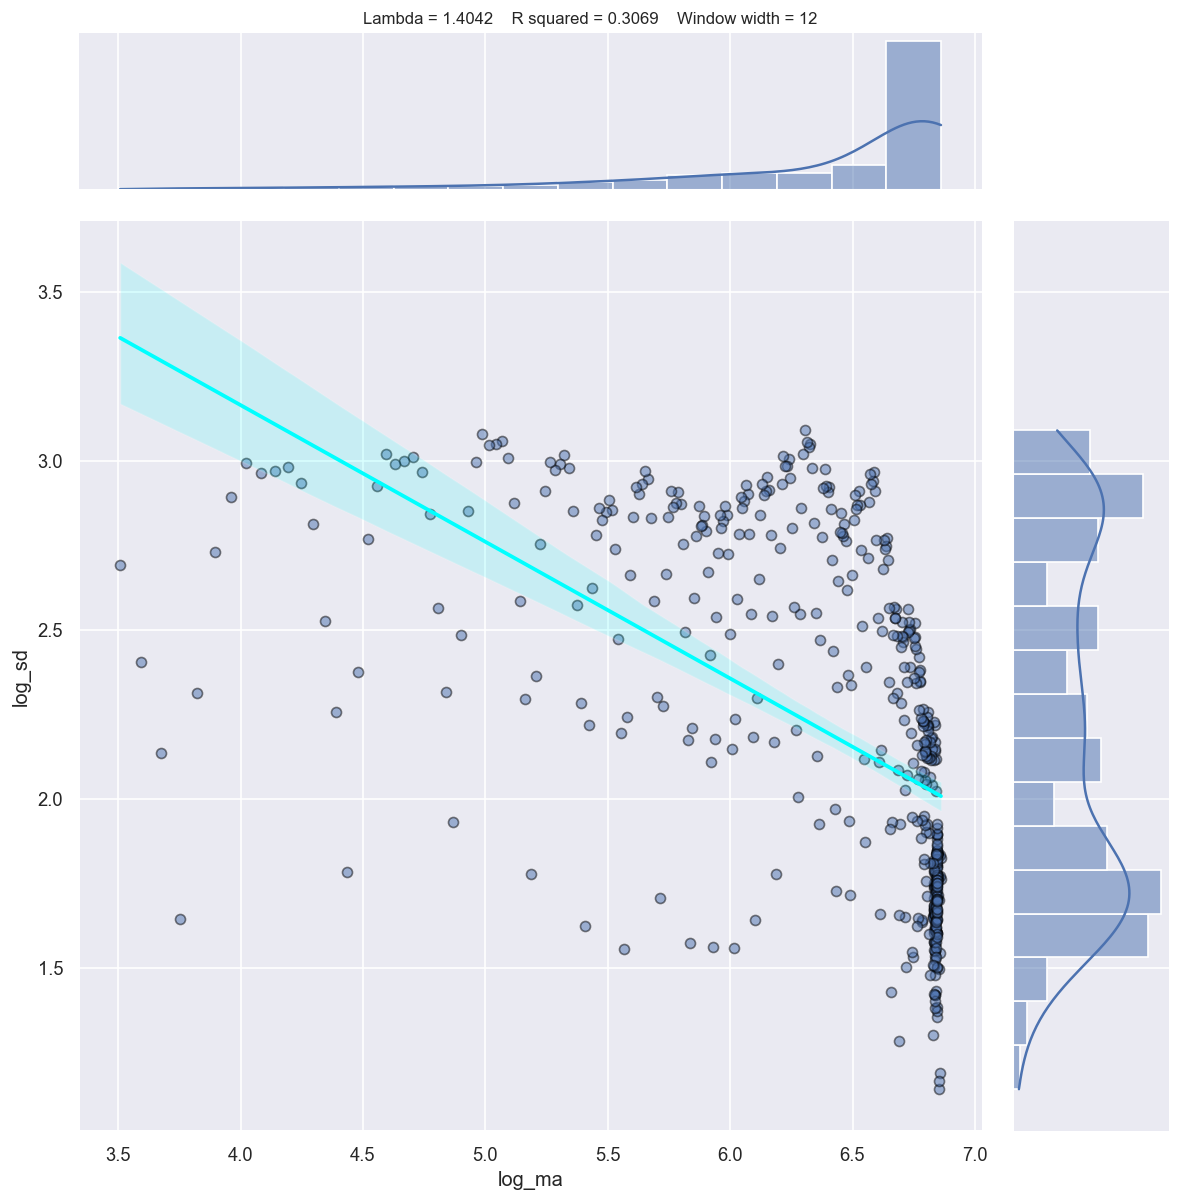

1.404243928636419

In [156]:
# Box-Cox transformation
boxcox_lambda_plot(df_7, window_width=12)

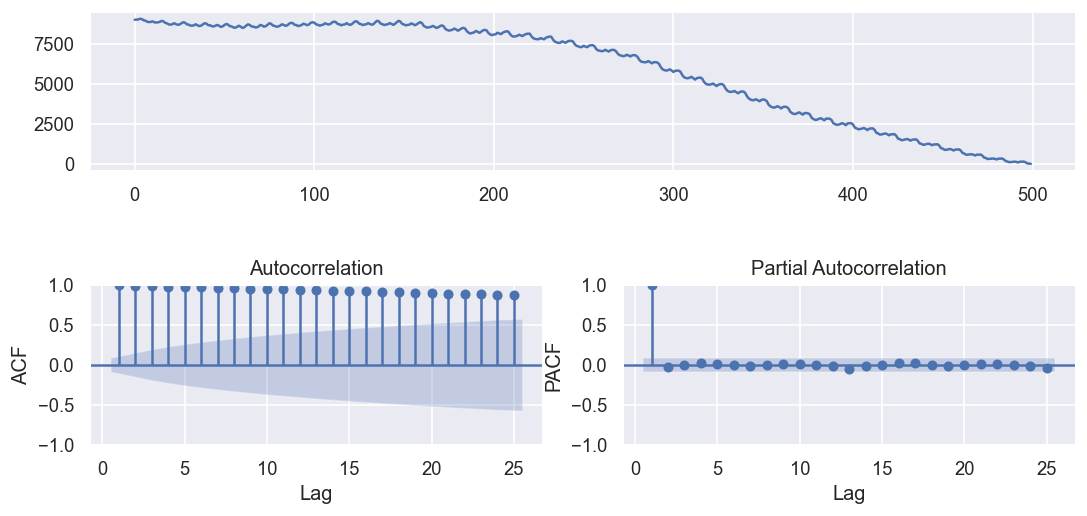

In [158]:
# Compute Box CoxPlot transformed data
BOX_COX = True
if BOX_COX:
    lmbda = 1.404 #Select lambda, en base a lo anterior deccidimos el valor de lambda
    z = st.boxcox(df_7.values[:,0],   lmbda = lmbda) #Convert series to positive if neccesary
    z,lmbda = st.boxcox(df_7.values[:,0] - min(df_7.values) + 1) #Convert to positive and automatic selection of lmbda, optimiza el valor de lambda, pero lo hacemos como la linea anterior indicano el lambda que queremos
    z = pd.DataFrame(z, columns=df_7.columns.values.tolist())
else:
    z = df_7

# Plot transformed data
ts_display(z)

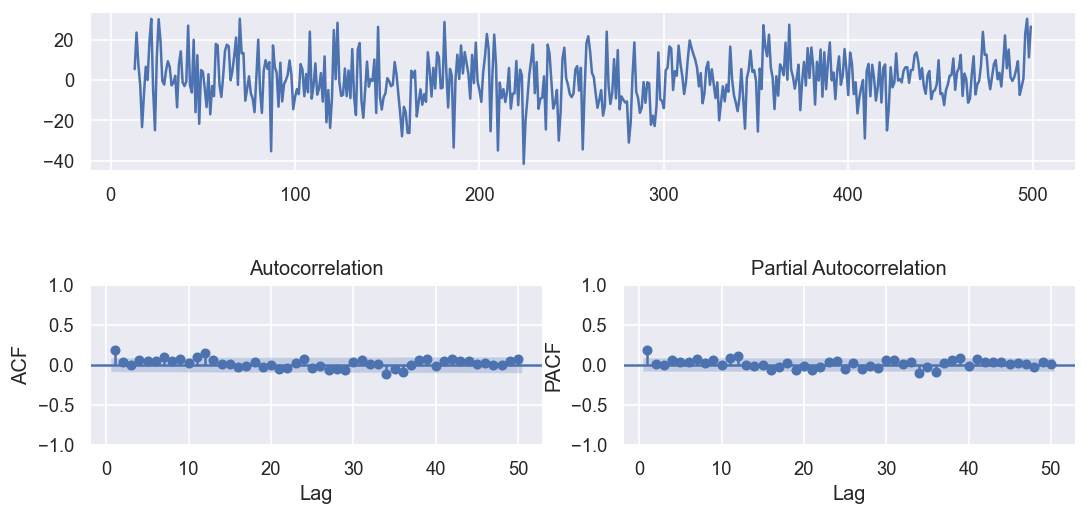

In [178]:
# Esto lo vamos a hacer para los modelos que ya son estacionarios en varianza.

# Difference of the time series

# Empezamos en d = 0 y D = 0. Esto significa que no hago ninguna transformación a la ser
# d = y(t) - y(t-1)  diferenciacion regular
# D = y(t) - y(t-s)  diferenciacion estacional

d = 1# con d=0 vemos en el grafico de autocorrelacion que se repite periodicamente, esto es que hay que probar con d=1. Con d=1  vemos que hace falta una diferenciacion estacional porque cambia en periodos, es decir que se repite un patron
D = 1
S = 12 # Seasonality of 12 days

Bz = z
for diff in range(d):
    Bz = Bz.diff().dropna() # drop first NA value
for seas_diff in range(D):
    Bz = Bz.diff(S).dropna() # drop first NA values
ts_display(Bz,lags=50)

# Ahora miramos y seria un MA4 O AR2 por ACF y PACF, vamos a ver que es lo que ocurre en la siguiente celda

In [184]:
# Fit model with estimated order
sarima_fit = SARIMAX(z, 
                    order=(1,1,0), # Regular components (p, d, q)
                    seasonal_order=(0, 1, 0, 12), # Seasonal components (P, D, Q)
                    trend= 'ct', # Type of trend: ['c','t','n','ct'] --> [constant, linear, no trend, constant and linear]
                    enforce_invertibility=False, 
                    enforce_stationarity=False).fit()

print(sarima_fit.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.78935D+00    |proj g|=  8.53579D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4      2      7      1     0     0   2.153D-04   3.789D+00
  F =   3.7893483832004184     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
                                     SARIMAX Results                                      
Dep. Variable:                           Series_7   No. Observations:                  500
Model:      

 This problem is unconstrained.


Ljung-Box test of residuals:
      lb_stat  lb_pvalue
25  30.920944    0.19165


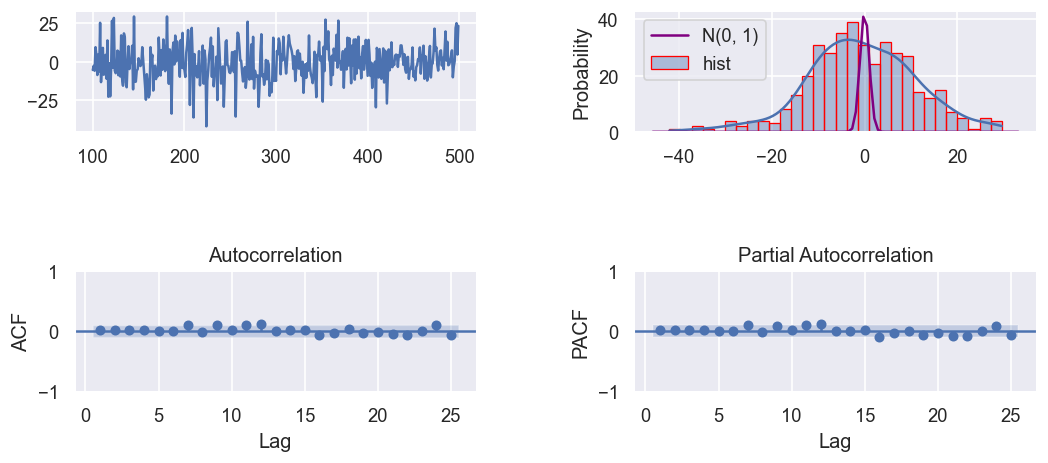

In [186]:
# Assuming df_1 is your DataFrame and sarima_fit is your SARIMA model
residuals_df_7 = pd.DataFrame(sarima_fit.resid.loc[100:])  # Adjust the index range as needed
check_residuals(residuals_df_7)
